# Modelo de Random Forest

Este notebook carga los datos ya preprocesados en `preprocesamiento.ipynb` (submuestra de 600 imágenes/clase, 64x64, splits train/val/test) y entrena un Random Forest para compararlo contra las CNNs y la red fully-connected.

**Por qué Random Forest** (ver también README): con imágenes de 64x64 a color cada foto tiene más de 12,000 valores de entrada. Random Forest maneja bien ese volumen sin necesitar PCA (a diferencia de SVM), y tiene hiperparámetros claros (número de árboles, profundidad máxima) para comparar varias corridas, tal como pide la rúbrica. Descartamos KNN por el curse of dimensionality y su lentitud al predecir.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_SEED = 42

In [2]:
DATA_PATH = Path("asl-alphabet/processed/asl_64x64_600pc.npz")
assert DATA_PATH.exists(), f"No se encontró {DATA_PATH}. Corre primero preprocesamiento.ipynb"

data = np.load(DATA_PATH, allow_pickle=True)

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
class_names = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Clases:", list(class_names))

Train: (12180, 64, 64, 3) (12180,)
Val:   (2610, 64, 64, 3) (2610,)
Test:  (2610, 64, 64, 3) (2610,)
Clases: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('nothing'), np.str_('space')]


## Aplanado de las imágenes

A diferencia de las CNN, Random Forest no entiende de estructura espacial, así que cada imagen 64x64x3 se convierte en un solo vector de 12,288 valores. También normalizamos de `uint8 [0,255]` a `float32 [0,1]`, igual que los demás modelos.

In [3]:
def preparar(X):
    X = X.astype(np.float32) / 255.0
    return X.reshape(X.shape[0], -1)

X_train_flat = preparar(X_train)
X_val_flat = preparar(X_val)
X_test_flat = preparar(X_test)

print("Shape aplanado (train):", X_train_flat.shape)

Shape aplanado (train): (12180, 12288)


## Búsqueda de hiperparámetros

Comparamos varias combinaciones de `n_estimators` (número de árboles) y `max_depth` (profundidad máxima) para mostrar cómo cambia el desempeño, tal como pide la rúbrica. Evaluamos cada combinación sobre el set de **validación** (no el de prueba, para no contaminarlo).

In [4]:
configs = [
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 200, "max_depth": 20},
    {"n_estimators": 300, "max_depth": None},
]

resultados = []
modelos = {}

for cfg in configs:
    t0 = time.time()
    rf = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf.fit(X_train_flat, y_train)
    tiempo_entrenamiento = time.time() - t0

    val_pred = rf.predict(X_val_flat)
    val_acc = accuracy_score(y_val, val_pred)

    nombre = f"n_estimators={cfg['n_estimators']}, max_depth={cfg['max_depth']}"
    modelos[nombre] = rf
    resultados.append({
        "config": nombre,
        "val_accuracy": val_acc,
        "tiempo_entrenamiento_seg": round(tiempo_entrenamiento, 1),
    })
    print(f"{nombre} -> val_accuracy={val_acc:.4f} ({tiempo_entrenamiento:.1f}s)")

df_resultados = pd.DataFrame(resultados).sort_values("val_accuracy", ascending=False)
df_resultados

n_estimators=100, max_depth=10 -> val_accuracy=0.9088 (15.1s)
n_estimators=100, max_depth=None -> val_accuracy=0.9644 (42.8s)
n_estimators=200, max_depth=20 -> val_accuracy=0.9659 (100.5s)
n_estimators=300, max_depth=None -> val_accuracy=0.9670 (93.2s)


,config,val_accuracy,tiempo_entrenamiento_seg
3,"n_estimators=300, max_depth=None",0.967050,93.2
2,"n_estimators=200, max_depth=20",0.965900,100.5
1,"n_estimators=100, max_depth=None",0.964368,42.8
0,"n_estimators=100, max_depth=10",0.908812,15.1


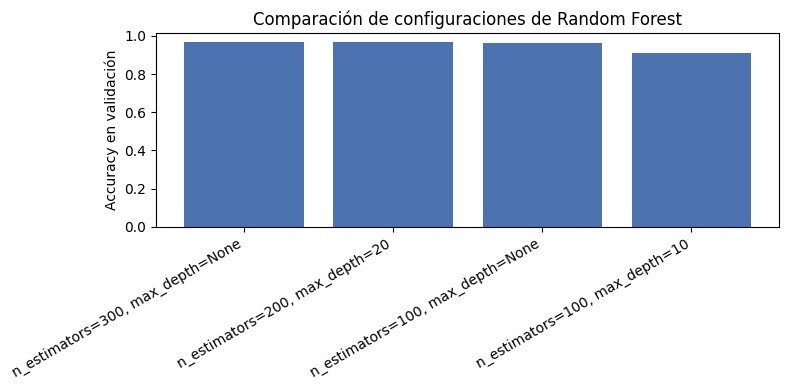

In [5]:
plt.figure(figsize=(8, 4))
plt.bar(df_resultados["config"], df_resultados["val_accuracy"], color="#4C72B0")
plt.ylabel("Accuracy en validación")
plt.xticks(rotation=30, ha="right")
plt.title("Comparación de configuraciones de Random Forest")
plt.tight_layout()
plt.show()

## Evaluación del mejor modelo sobre el set de prueba

Tomamos la configuración con mejor `val_accuracy` y la evaluamos una sola vez sobre el set de prueba (que no se tocó hasta ahora).

In [6]:
mejor_config = df_resultados.iloc[0]["config"]
mejor_modelo = modelos[mejor_config]

test_pred = mejor_modelo.predict(X_test_flat)
test_acc = accuracy_score(y_test, test_pred)

print(f"Mejor configuración: {mejor_config}")
print(f"Accuracy en test: {test_acc:.4f}")
print()
print(classification_report(y_test, test_pred, target_names=class_names))

Mejor configuración: n_estimators=300, max_depth=None
Accuracy en test: 0.9655

              precision    recall  f1-score   support

           A       0.94      0.92      0.93        90
           B       0.94      0.93      0.94        90
           C       0.97      0.94      0.96        90
           D       0.89      0.99      0.94        90
           E       1.00      0.88      0.93        90
           F       0.96      1.00      0.98        90
           G       1.00      0.99      0.99        90
           H       0.99      0.99      0.99        90
           I       0.99      1.00      0.99        90
           J       1.00      0.99      0.99        90
           K       0.99      1.00      0.99        90
           L       1.00      1.00      1.00        90
           M       0.96      0.99      0.97        90
           N       0.99      0.99      0.99        90
           O       0.97      0.97      0.97        90
           P       0.98      0.94      0.96        90
 

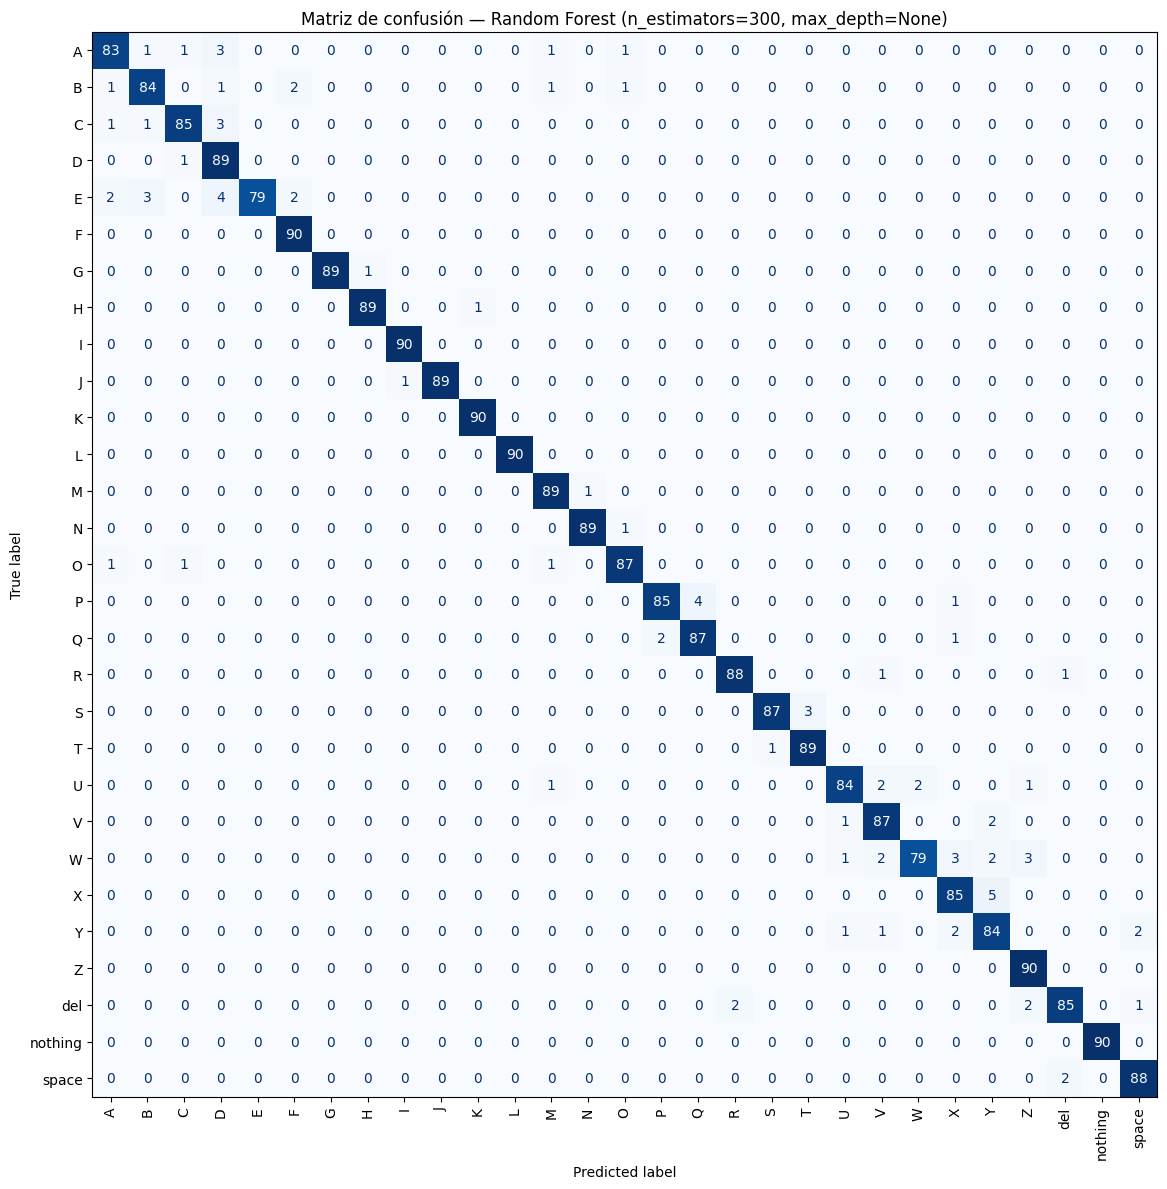

In [7]:
cm = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap="Blues")
plt.title(f"Matriz de confusión — Random Forest ({mejor_config})")
plt.tight_layout()
plt.show()

## ¿Qué clases confunde más el modelo?

Revisamos los pares de clases con más confusiones en la matriz, para ver si coinciden con los grupos ya identificados en el EDA (M/N/S, U/V/R/W/X).

In [8]:
cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confusion = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_sin_diagonal[i, j] > 0:
            pares_confusion.append({
                "real": class_names[i],
                "predicho": class_names[j],
                "cantidad": cm_sin_diagonal[i, j],
            })

df_confusion = pd.DataFrame(pares_confusion).sort_values("cantidad", ascending=False)
df_confusion.head(15)

,real,predicho,cantidad
45,X,Y,5
16,E,D,4
26,P,Q,4
15,E,B,3
12,C,D,3
2,A,D,3
32,S,T,3
42,W,X,3
44,W,Z,3
51,del,Z,2


## Importancia de variables (píxeles)

Visualizamos qué regiones de la imagen (64x64) pesan más para el modelo, reconstruyendo el vector de importancias como imagen. Como el modelo recibe los 3 canales de color por separado, promediamos la importancia entre canales por posición de píxel.

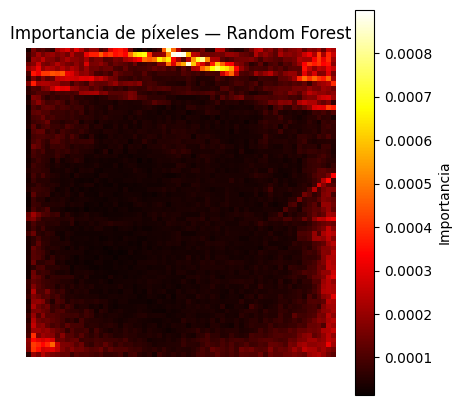

In [9]:
importancias = mejor_modelo.feature_importances_.reshape(64, 64, 3).mean(axis=2)

plt.figure(figsize=(5, 5))
plt.imshow(importancias, cmap="hot")
plt.colorbar(label="Importancia")
plt.title("Importancia de píxeles — Random Forest")
plt.axis("off")
plt.show()

## Guardar el modelo

Guardamos el mejor modelo para poder usarlo después en el ejercicio 8 (pruebas con fotos propias) si termina siendo el mejor algoritmo general.

In [10]:
import joblib

MODEL_DIR = Path("asl-alphabet/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(mejor_modelo, MODEL_DIR / "random_forest.joblib")
print("Modelo guardado en:", (MODEL_DIR / "random_forest.joblib").resolve())

Modelo guardado en: C:\Users\isabe\OneDrive\Escritorio\Lab3-DataScience\asl-alphabet\models\random_forest.joblib


## Discusión de resultados

**Configuración ganadora**: `n_estimators=300, max_depth=None` con 96.70% de accuracy en validación, apenas por encima de `n_estimators=200, max_depth=20` (96.59%) y de `n_estimators=100, max_depth=None` (96.44%). Tal como se esperaba, limitar la profundidad de los árboles es lo que más le costó al modelo, porque con más de 12,000 variables de entrada los árboles necesitan poder crecer bastante para separar bien las 29 clases. Entre las configuraciones con árboles sin límite de profundidad, agregar más árboles (100 → 300) dio una mejora modesta (96.44% → 96.70%) a cambio de más del doble de tiempo de entrenamiento (42.8s → 93.2s).

**Test vs. validación**: el accuracy en test (96.55%) quedó prácticamente igual al de validación (96.70%), una diferencia de apenas 0.15 puntos. Esto indica que no hay sobreajuste relevante y el modelo generaliza bien a datos que nunca vio, no solo memorizó el set de validación.

**Confusiones vs. EDA**: los pares más confundidos fueron X→Y (5 casos), E→D y P→Q (4 casos cada uno), y W→X, W→Z, S→T, C→D, A→D (3 casos cada uno). Esto coincide parcialmente con lo encontrado en el EDA: el grupo U/V/R/W/X identificado como el más confuso en el heatmap de similitud sí aparece reflejado aquí (W→X, W→Z, X→Y son todas letras de esa zona del alfabeto). En cambio, el grupo M/N/S casi no aparece. De esas tres, solo S se confunde (con T, no con M o N), lo que sugiere que Random Forest, al trabajar sobre los píxeles crudos en vez de la forma de la mano, no distingue esas letras exactamente por las mismas razones que se ven a simple vista en las imágenes promedio del EDA.